2. Execute Simon’s algorithm and observe the hidden bit string.

In [1]:
!pip install qiskit
!pip install qiskit-aer
!pip install pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 84.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=47fe64bc17a58235a9638ad84ebc01a794cd6c94284c6d8726cccf2e883d1c79
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Results: {'11': 503, '00': 521}


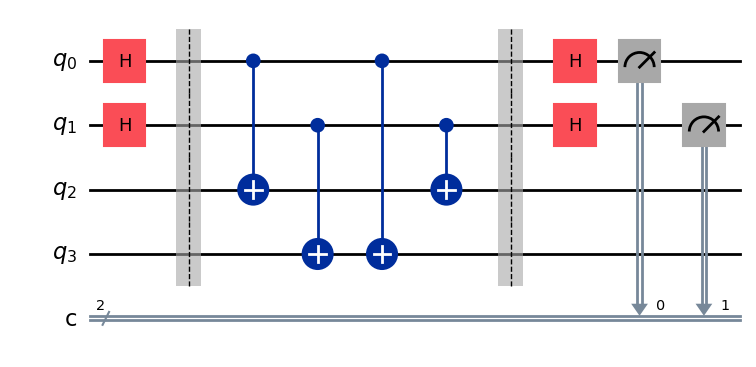

In [3]:
#2. Execute Simon’s algorithm and observe the hidden bit string

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# Number of qubits (n=2 → total = 2n = 4)
n = 2
qc = QuantumCircuit(2*n, n)

# Step 1: Hadamard on input qubits
qc.h([0, 1])
qc.barrier()

# Step 2: Oracle for s = "11"
# Copy input to output
qc.cx(0, 2)
qc.cx(1, 3)

# Apply dependency to enforce f(x) = f(x ⊕ s)
qc.cx(0, 3)
qc.cx(1, 2)

qc.barrier()

# Step 3: Hadamard again
qc.h([0, 1])

# Step 4: Measure
qc.measure([0, 1], [0, 1])

# Run simulation
backend = AerSimulator()
result = backend.run(transpile(qc, backend), shots=1024).result()

counts = result.get_counts()
print("Results:", counts)

qc.draw('mpl')